# Results Notebook

This Notebook contains the code for generating all figures and tables in the paper, using raw results from the experimaestro workspace.

# Imports and Utils

### Labeling

In [1]:
from format import loss_names, backbone_names, DATASET_TO_ABB, aggregations
from format import backbone_names_mice as backbone_names_mice
from pathlib import Path
import matplotlib.pyplot as plt

xps_root = Path.home() / "experiments" / "JZ" / "cross_encoders"
xps_root = Path.home() / "code" / "experiments" / "JZ" / "cross_encoders"
fig_dir = Path("./figures/mice")

ignore_losses = ["infoNCE_norm_size=True"]


# --- Settings ---
FONT_SIZE = 14

# Set font for publication quality
plt.rcParams.update(
    { 
    'font.family': 'DejaVu Serif',
    'font.serif': [''],
    'font.size': FONT_SIZE,
    'axes.labelsize': FONT_SIZE - 3,
    'axes.titlesize': FONT_SIZE,
    'xtick.labelsize': FONT_SIZE - 2,
    'ytick.labelsize': FONT_SIZE - 2,
    'legend.fontsize': FONT_SIZE-3,
    }
)

backbone_colors = {
    "microsoft/MiniLM-L12-H384-uncased": "#1f77b4", 
    "jhu-clsp/ettin-encoder-17m": "#f5d268",
    "jhu-clsp/ettin-encoder-32m": "#f29f28",
    "jhu-clsp/ettin-encoder-68m": "#ea650a",
    "jhu-clsp/ettin-encoder-150m": "#d6191b",
    "jhu-clsp/ettin-encoder-400m": "#ff1111",
    "google/electra-base-discriminator": "#9467bd",
    "bert-base-uncased": "#4422bd",
    "Other": "#7f7f7f"
}


plt.style.use('ggplot')
print("using xps root:", xps_root)

/Users/victor/code/projects/cross-encoders/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


using xps root: /Users/victor/code/experiments/JZ/cross_encoders


### Imports and Utils

In [2]:
from pathlib import Path
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dataclasses import field
from flops import (
    get_transformer_params,
    compute_flops_prettr,
    compute_flops_mice,
    compute_flops_CrossEncoder,
    compute_flops_colbert,
)
from experimaestro import Config

# Set font for publication quality
# plt.rcParams['font.family'] = 'Times New Roman'
# 1. Configure Matplotlib for ACM Style
plt.rcParams.update(
    { 
    'font.family': 'DejaVu Serif',
    'font.serif': [''],
    'font.size': FONT_SIZE,
    'axes.labelsize': 11,
    'axes.titlesize': FONT_SIZE,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': FONT_SIZE,
    }
)
plt.style.use("ggplot")
# sns.set_theme(style="whitegrid")


def get_color(hf_id: str):
    if hf_id in backbone_colors.keys():
        return backbone_colors[hf_id]
    return backbone_colors["Other"]

backbone_colors_name = {}
for hf_id, c in backbone_colors.items():
    name = hf_id.split("/")[-1].lower(        
    ).replace("-","").replace("_",""
    ).replace("encoder",""
    ).replace("l12h384uncased",""
    ).replace("basediscriminator","")

    backbone_colors_name[name] = c

def get_color_name(name: str):
    name = name.lower().replace("-", "")
    for bname, c in backbone_colors_name.items():
        if bname in name:
            return c
    return backbone_colors["Other"]


def get_last_xp(xp_id, force_date=None, verbose=True) -> str:
    dates = sorted(list((xps_root / xp_id).glob("*")))
    if verbose:
        print(f"Found dates for {xp_id}: {[d.name for d in dates]}")

    # parse and get most recent date
    if force_date is not None:
        forced_date_path = xps_root / xp_id / force_date
        if forced_date_path in dates:
            if verbose:
                print(f"Using forced date for {xp_id}: {forced_date_path.name}")
            return forced_date_path
        else:
            if verbose:
                print(f"Forced date {force_date} not found for xp {xp_id}")

    dates = [d for d in dates if re.match(r"\d+_\d+", d.name)]

    last = ""
    # last = max(dates, key=lambda d: d.name)
    for date in dates[::-1]:
        if (xps_root / xp_id / date / "results" / "results.csv").exists():
            last = date
            break

    if not last:
        print(f"No valid dates found for xp {xp_id}, returning dry-run")
        last = "dry-run"

    return xps_root / xp_id / last


def get_results(xp_path, verbose=True) -> pd.DataFrame:
    path = xp_path / "results"
    csv_files = list(path.glob("results.csv"))

    if len(csv_files):
        return pd.read_csv(csv_files[0])
    else:
        return None


def process_results(results) -> pd.DataFrame:
    # labels1 = results.iloc[0]
    if results is None:
        return None
    if "tag" in list(results.columns)[-1]:
        print("V1 xp -> Rerun to get new df format !")
        labels1 = results.iloc[0]
        labels2 = results.iloc[1]
        results = results.iloc[3:]
    else:
        labels1 = [l1.split(".")[0] for l1 in results.columns]
        labels2 = results.iloc[0]
        results = results.iloc[2:]

    labels = [
        f"{l1}{'_' + str(l2) if str(l2) != 'nan' else ''}"
        for l1, l2 in zip(labels1, labels2)
    ]

    labels[0] = "dataset"
    results.columns = labels
    # Select columns containing 'mean' or 'var' (case-insensitive)
    cols_to_convert = results.filter(regex="(?i)mean|var").columns

    # Convert those columns to numeric, turning errors (like 'None' strings) into NaN
    results[cols_to_convert] = results[cols_to_convert].apply(
        pd.to_numeric, errors="coerce"
    )

    return results


def get_aggregated_stats(results, group_cols, metrics):
    # 3. Ensure numeric types
    all_cols = []
    for m in metrics:
        all_cols.extend([f"{m}_mean", f"{m}_var"])

    for col in all_cols:
        results[col] = pd.to_numeric(results[col], errors="coerce")

    # 4. Compute the Simple Average of Means and Variances
    #    We do NOT add the inter-dataset variance here.
    #    We act as if the datasets are fixed strata.
    aggregated_stats = results.groupby(group_cols, dropna=False)[all_cols].mean()

    # 5. Rename columns for clarity
    #    Renaming 'AP_mean' -> 'Grand_Mean_AP' and 'AP_var' -> 'Average_Var_AP'
    rename_dict = {}
    for m in metrics:
        rename_dict[f"{m}_mean"] = f"{m}_Grand_Mean"
        rename_dict[f"{m}_var"] = f"{m}_Average_Var"

    aggregated_stats = aggregated_stats.rename(columns=rename_dict)

    return aggregated_stats
    # Add experiment label


def get_aggregated_df(df, datasets, name):
    """
    Returns a NEW DataFrame with aggregated means for specific datasets.
    Does not modify the original df.
    """
    # 1. Identify metric columns and metadata columns
    metric_cols = df.filter(regex="(?i)mean|var").columns.tolist()
    # Metadata columns are everything EXCEPT the metrics and the dataset name
    metadata_cols = [c for c in df.columns if c not in metric_cols and c != "dataset"]

    # 2. Filter rows for the specified datasets
    subset = df[df["dataset"].isin(datasets)].copy()
    subset[metric_cols] = subset[metric_cols].apply(pd.to_numeric, errors="coerce")

    # 3. Group by ALL metadata columns to preserve them
    # This keeps 'base', 'loss', 'scorer', 'arch', etc. intact
    new_df = subset.groupby(metadata_cols, as_index=False)[metric_cols].mean()

    # 4. Assign the new dataset aggregate name
    new_df["dataset"] = name

    # Reorder for readability: dataset first, then metadata, then metrics
    cols = ["dataset"] + metadata_cols + metric_cols
    return new_df[cols]


from dataclasses import dataclass


@dataclass
class ModelResults:
    name: str

    xp_id: str

    path: Path
    """path to the model directory inf HF format"""

    hf_id: str = None

    results: pd.DataFrame = None
    """Results dataframe"""

    flops_results: dict = None
    """Results of FLOPs benchmark"""

    benchmark: dict = field(default_factory=dict)
    """Performance benchmark"""

    benchmark_precompute: dict = field(default_factory=dict)
    """Performance benchmark"""


def get_models(xp_path) -> list:
    path = xp_path / "results" / "models"
    # list directory and find csv files
    models = []

    model_dirs = [d for d in path.glob("*") if d.is_dir()]
    print(f"Found model directories in {path}: {[d.name for d in model_dirs]}")

    for model_dir in model_dirs:
        csv_file = model_dir / "results.csv"
        name = model_dir.name.replace("cross-encoder", "Cross-Encoder")
        if not csv_file.exists():
            print(f"Expected csv file not found in {model_dir}")
            continue
        else:
            models.append(
                ModelResults(
                    name=name,
                    xp_id=xp_path.parent.name,
                    path=model_dir,
                    results=pd.read_csv(csv_file),
                )
            )
    return models


def get_hf_id(model_cfg: Config) -> str:
    model_class = type(model_cfg).__name__.lower()
    if "mice" in model_class:
        return model_cfg.hf_id
    elif "prettr" in model_class:
        return model_cfg.encoder.config.hf_id
    elif "hfcrossscorer" in model_class:
        return model_cfg.encoder.config.hf_id
    elif "colbert" in model_class:
        return model_cfg.encoder.encoder.model.config.hf_id
    else:
        return "unknown"


def compute_flops_model(
    model_cfg: Config, seq_len=512, query_len=32, precompute_docs=False
):
    """Computes the FLOPs of a model based on its configuration. Returns a tuple (model_flops, baseline_flops)"""
    model_class = type(model_cfg).__name__.lower()
    hf_id = get_hf_id(model_cfg)
    d, d_ff, nlayers = get_transformer_params(hf_id)

    if "mice" in model_class:
        return compute_flops_mice(
            model_cfg,
            d,
            d_ff,
            nlayers,
            seq_len=seq_len,
            query_len=query_len,
            precompute_docs=precompute_docs,
        )
    elif "prettr" in model_class:
        return compute_flops_prettr(
            model_cfg.join_layer,
            d,
            d_ff,
            nlayers,
            seq_len=seq_len,
            query_len=query_len,
            precompute_docs=precompute_docs,
        )
    elif "colbert" in model_class:
        return compute_flops_colbert(
            d,
            d_ff,
            nlayers,
            seq_len=seq_len,
            query_len=query_len,
            precompute_docs=precompute_docs,
        )
    elif "hfcrossscorer" in model_class:
        return compute_flops_CrossEncoder(
            d,
            d_ff,
            nlayers,
            seq_len=seq_len,
        )
    else:
        print(
            f"Unknown model class {model_class} for model {model_cfg}, skipping FLOPs computation for this model."
        )
        return 0, 1



def compute_flops_colbert_id(
    hf_id: str, seq_len=512, query_len=32, precompute_docs=False
):
    """Computes the FLOPs of a model based on its configuration. Returns a tuple (model_flops, baseline_flops)"""
    d, d_ff, nlayers = get_transformer_params(hf_id)
    return compute_flops_colbert(
        d,
        d_ff,
        nlayers,
        seq_len=seq_len,
        query_len=query_len,
        precompute_docs=precompute_docs,
        )

print(f"found xps in {xps_root}")
all_xps = list(xps_root.glob("*"))
for xp in sorted(all_xps):
    print(f"- {xp.name}")

found xps in /Users/victor/code/experiments/JZ/cross_encoders
- .DS_Store
- RankDistiLLMNeg_base
- RankDistiLLMNeg_mini
- baseline_MiniLM_CE
- baseline_colbert_minilm
- baseline_mores
- baseline_prettr_miniLM_l8
- baseline_small_CE
- baseline_small_CE_withruns
- baselines_base
- colbertNeg_base
- colbertNeg_infoNCE_precision
- colbertNeg_mini
- comparison_precision
- core_base
- core_base_deberta
- core_base_deberta_top100
- core_base_ettin
- core_base_ettin_1b
- core_base_ettin_1b_bs=16
- core_base_ettin_scaling
- core_base_ettin_scaling_except_1b
- core_base_paper
- core_mini
- core_mini_debug
- cross_scorer_evaluation
- cross_scorer_evaluation_debug
- debug_CE_training
- debug_mice_plaid
- debug_mice_training
- eval_masked_step0
- eval_scorer_bm25_top1000
- eval_scorer_debug
- eval_scorer_top100
- eval_scorer_top1000
- hyperparams_search_contrastive
- local_model_evaluation
- reproduction_RankDistiLLM
- train_mice_bert_l4+3
- train_mice_bert_l48+3
- train_mice_electra_l48+3
- train_

# Main Figures

## Mice-$\ell$ Y+X

### Loading

In [ ]:
# Main table
import pandas as pd

xps = {
    "train_mice_miniLM_l4+X": r"MICE MiniLM-$\ell$4+X",
    # "train_mice_ettin_17m-l3+X": r"MICE Ettin-17m-$\ell$3+X", # don't use it - too small
    "train_mice_ettin_32m-l6+X": r"MICE Ettin-32m-$\ell$6+X",
    # "train_mice_ettin_68m-l6+X": r"Mice Ettin-68m-$\ell$6+X",
}

def get_xp_df(xp):
    xp_path = xps_root / xp / "dry-run"
    xp_path = xps_root / xp
    xp_path = get_last_xp(xp_path)
    print(f"Using xp path: {xp_path}")
    df = process_results(get_results(xp_path))

    datasets = df["dataset"].unique()
    print(f"{len(datasets)} unique datasets : {list(datasets)}")
    # print(f"unique losses : {list(df['loss'].unique())}")
    # print(f"Backbones : {list(df['base'].unique())}")

    display(df.head())
    return df

xp_dfs = {xp: get_xp_df(xp) for xp in xps.keys()}

### Plotting

In [ ]:
#filter 'n_contextualization_layers' is not null
metric = "nDCG@10"
metric_mean = f"{metric}_mean"
metric_var = f"{metric}_var"
y_key = "n_interaction_layers"
figsize=(5, 2.5)
capsize=2
capthick=1

# Plot for each dataset
for dataset_name in ["In Domain"]:
    # Create figure with publication quality
    fig, ax = plt.subplots(figsize=figsize)
    max_y = 1
    for xp, df in xp_dfs.items():
        name = xps[xp]
        color = get_color_name(name)
        # plot nDCG@10_mean /pm nDCG@10_var as a function of n_contextualization_layers
        df[y_key] = pd.to_numeric(df[y_key], errors="coerce")
        df[metric_mean] = pd.to_numeric(df[metric_mean], errors="coerce")
        df[metric_var] = pd.to_numeric(df[metric_var], errors="coerce")
        df = df[df[y_key].notnull()]
        dataset_df = df[df["dataset"] == dataset_name].copy()
        max_y = max(max_y, int(max(df[y_key].unique())))
        if len(dataset_df) == 0:
            print(f"No data found for dataset: {dataset_name}")
            continue
        
        # Group by n_interaction_layers and compute aggregated statistics
        grouped = dataset_df.groupby(y_key, dropna=False).agg(
            mean_nDCG=(metric_mean, "mean"),
            std_nDCG=(metric_var, lambda x: np.sqrt(x.mean())),  # sqrt of mean variance
            count=(metric_mean, "count")
        ).reset_index()

        grouped = grouped.sort_values(y_key)

        ax.errorbar(
            grouped[y_key],
            grouped["mean_nDCG"],
            yerr=grouped["std_nDCG"],
            fmt="o--",
            markersize=5,
            linewidth=1,
            capsize=capsize,
            capthick=capthick,
            color=color,
            # ecolor="#1f77b4",
            alpha=0.8,
            label=f"{xps[xp]}"
        )

    # Formatting
    ax.set_xlabel("# Interaction Layers", fontsize=FONT_SIZE, fontweight="normal")
    ax.set_ylabel(f"ID - nDCG@10", fontsize=FONT_SIZE, fontweight="normal")
    # ax.set_title(f"{metric} vs Interaction Layers ({dataset_name})", fontsize=12, fontweight="normal")
    ax.grid(True, alpha=0.3, linestyle="--")
    ax.legend(frameon=True, loc="best", fontsize=FONT_SIZE-3)
    # ax.set_ylim(.50, .512)  # nDCG is between 0 and 1
    plt.tight_layout()
    plt.savefig(fig_dir / f"nDCG10_vs_InteractionLayers_{dataset_name.replace(' ', '_')}.pdf")
    plt.show()
    # Display grouped results
    # print(f"\nAggregated nDCG@10 Statistics by Contextualization Layers ({dataset_name}):")
    # display(grouped)

## Mice X+3

### Loading

In [ ]:
# Main table
import pandas as pd

xps = {
    "train_mice_miniLM_lX+3": "MICE MiniLM-$\\ell$X+3",
    "train_mice_miniLM_lX+3_bias": "MICE MiniLM-$\\ell$X+3 Lex",

    "train_mice_ettin32m_lX+4": "MICE Ettin-32m-$\\ell$X+4",
    "train_mice_ettin32m_lX+4_bias": "MICE Ettin-32m-$\\ell$X+4 Lex",
    # "train_mice_ettin17_lX+3": "Mice Ettin-17m-lX+3", #don't use it - too small
    # "train_mice_ettin68_lX+3": "Mice Ettin-68m-lX+3",
    # "train_mice_ettin_68m_bias": "Mice-$\\ell$8+3+Lex",

    # "train_mice_ettin32_lX+3": "Mice Ettin-32m-lX+3",
    # "train_mice_ettin32_lX+3_bias": "Mice Ettin-32m-lX+3 Lex",
    
}

def get_xp_df(xp):
    xp_path = xps_root / xp / "dry-run"
    xp_path = xps_root / xp
    xp_path = get_last_xp(xp_path)
    print(f"Using xp path: {xp_path}")
    df = process_results(get_results(xp_path))

    datasets = df["dataset"].unique()
    print(f"{len(datasets)} unique datasets : {list(datasets)}")
    # print(f"unique losses : {list(df['loss'].unique())}")
    # print(f"Backbones : {list(df['base'].unique())}")

    display(df.head())
    return df

xp_dfs = {xp: get_xp_df(xp) for xp in xps.keys()}

### Plotting

In [ ]:
from format import backbone_nlayers
#filter 'n_contextualization_layers' is not null
metric = "nDCG@10"
metric_mean = f"{metric}_mean"
metric_var = f"{metric}_var"
figsize=(5, 3)

# Plot for each dataset
for dataset_name in ["In Domain"]:
    # Create figure with publication quality
    fig, ax = plt.subplots(figsize=figsize)

    for xp, df in xp_dfs.items():
        base = df["base"].iloc[0]
        base_nlayers = backbone_nlayers.get(base,0)
        name = xps[xp]
        color = get_color_name(name)

        if not base_nlayers:
            print(f"Warning: Backbone {base} not found in backbone_nlayers mapping. Skipping normalization for this xp.")   
            continue
        # plot nDCG@10_mean /pm nDCG@10_var as a function of n_contextualization_layers
        df["n_contextualization_layers"] = pd.to_numeric(df["n_contextualization_layers"], errors="coerce")
        df[metric_mean] = pd.to_numeric(df[metric_mean], errors="coerce")
        df[metric_var] = pd.to_numeric(df[metric_var], errors="coerce")
        df = df[df["n_contextualization_layers"].notnull()]
        dataset_df = df[df["dataset"] == dataset_name].copy()
        if len(dataset_df) == 0:
            print(f"No data found for dataset: {dataset_name}")
            continue
        
        # Group by n_contextualization_layers and compute aggregated statistics
        grouped = dataset_df.groupby("n_contextualization_layers", dropna=False).agg(
            mean_nDCG=(metric_mean, "mean"),
            std_nDCG=(metric_var, lambda x: np.sqrt(x.mean())),  # sqrt of mean variance
            count=(metric_mean, "count")
        ).reset_index()
        
        grouped = grouped.sort_values("n_contextualization_layers")
        ys = grouped["mean_nDCG"].values
        xs = grouped["n_contextualization_layers"].values
        xs_norm = xs / base_nlayers
        ax.errorbar(
            x=xs_norm,
            y=ys,
            yerr=grouped["std_nDCG"],
            fmt= "o-" if "lex" in name.lower() else ".--",
            markersize=4,
            linewidth=1,
            capsize=capsize,
            capthick=capthick,
            color=color,
            # ecolor="#1f77b4",
            alpha=0.8,
            label=name
        )

    # Formatting
    ax.set_xlabel("#Contextualization Layers / #Base Layers", fontsize=FONT_SIZE, fontweight="normal")
    ax.set_ylabel(f"ID - nDCG@10", fontsize=FONT_SIZE, fontweight="normal")
    # ax.set_title(f"{metric} vs Contextualization Layers ({dataset_name})", fontsize=12, fontweight="normal")
    ax.grid(True, alpha=0.3, linestyle="--")
    ax.legend(frameon=True, loc="best", fontsize=FONT_SIZE - 3)
    # ax.set_ylim(.50, .512)  # nDCG is between 0 and 1
    plt.tight_layout()
    print(f"\nAggregated nDCG@10 Statistics by Contextualization Layers ({dataset_name}):")
    plt.savefig(fig_dir / f"nDCG10_vs_ContextLayers_{dataset_name.replace(' ', '_')}.pdf")
    plt.show()
    # Display grouped results
        # display(grouped)

# Table Mice Results

In [73]:
# Main table
import pandas as pd

# Configuration
metric = "nDCG@10"

datasets_to_keep = aggregations["In Domain"] + aggregations["BEIR13"] + ["In Domain", "BEIR13"]

xps = {
    # baselines
    "baseline_small_CE": "Baseline",
    "baselines_base": "Baseline",
    "baseline_colbert_minilm": "ColBERT",
    "baseline_mores": "MORES-$\\ell$10-d12+2",
    "baseline_prettr_miniLM_l8": "PreTTR-$\\ell$8+4",
    # Mice Models
    
    # MiniLM   (l12)
    "train_mice_miniLM_l4": "MICE-$\\ell$4+3",
    "train_mice_miniLM_l4+3_bias": "MICE-$\\ell$4+3 Lex",
    "train_mice_miniLM_l4+all": "MICE-$\\ell$4+all",
    "train_mice_miniLM_l8+3": "MICE-$\\ell$8+3",
    "train_mice_miniLM_l8+3_bias": "MICE-$\\ell$8+3 Lex",
    "train_mice_miniLM_l8+all_bias": "MICE-$\\ell$8+all Lex", 
        # Ettin

    # 32M 
    "train_mice_ettin32m_l3+4": "MICE-$\\ell$3+4",
    "train_mice_ettin32m_l3+4_bias": "MICE-$\\ell$3+4 Lex",
    "train_mice_ettin32m_l6+4": "MICE-$\\ell$6+4",
    "train_mice_ettin32m_l6+4_bias": "MICE-$\\ell$6+4 Lex",
        # Optional
    # "train_mice_ettin_32m": "MICE-$\\ell$6+3",
    # "train_mice_ettin32m_l6+3_bias": "MICE-$\\ell$6+3 Lex",
    # "train_mice_ettin32m_l4+4": "MICE-$\\ell$4+4",

        # ELECTRA
    "train_mice_electra_l8+3": "MICE-$\\ell$8+3",
    "train_mice_electra_l8+3_bias": "MICE-$\\ell$8+3 Lex",
    
    # "train_mice_ettin_17m": "MICE-$\\ell$3+3",
        # 68m
    "train_mice_ettin_68m": "MICE-$\\ell$8+3",
    "train_mice_ettin_68m_bias": "MICE-$\\ell$8+3+Lex",
    "train_mice_ettin68m_l10+4_bias": "MICE-$\\ell$10+4+Lex",
    
    # "train_mice_ettin_150m": "test",
    # "train_mice_ettin150-l12+3": "MICE-$\\ell$12+3",
    "train_mice_ettin150-l12+3_bias": "MICE-$\\ell$12+4 Lex", #typo in xp id - its 12+4

    # "train_mice_ettin400-l16+4": "MICE-$\\ell$12+4",
}
xp_models = {}
xp_dfs = {}

## Loading

In [74]:

for xp in xps.keys():
    xp_path = xps_root / xp / "dry-run"
    xp_path = xps_root / xp
    xp_path = get_last_xp(xp_path)
    print(f"\nxp path: {xp_path}")

    df = process_results(get_results(xp_path, verbose=False))
    if df is None:
        print(f"#### ERROR - no results for {xp}\n\n")
        continue
    datasets = df["dataset"].unique()
    backbones = list(df['base'].unique())
    print(f" - {len(datasets)} unique datasets : {list(datasets)}")
    print(f" - {len(backbones)} unique backbones : {backbones}")

    xp_dfs[xp] = df
    xp_models[xp] = get_models(xp_path)

Found dates for /Users/victor/code/experiments/JZ/cross_encoders/baseline_small_CE: ['.DS_Store', '20260428_093714', '20260428_185727', '20260429_150025', '20260430_112724', '20260430_113205', '20260430_121822', '20260504_182428', '20260511_181552', '20260512_220506', '20260513_085602', '20260514_145145', '20260514_145549', '20260515_083354', '20260520_110548', 'current', 'dry-run', 'lock']

xp path: /Users/victor/code/experiments/JZ/cross_encoders/baseline_small_CE/20260520_110548
 - 27 unique datasets : ['BEIR13', 'In Domain', 'Lotte-S', 'arguana', 'climate_fever', 'dbpedia', 'fever', 'fiqa', 'hotpotqa', 'lotte_lifestyle', 'lotte_recreation', 'lotte_science', 'lotte_technology', 'lotte_writing', 'mean', 'minified', 'msmarco_dev', 'nfcorpus', 'nq', 'quora', 'robust04', 'scidocs', 'scifact', 'touche', 'trec2019', 'trec2020', 'trec_covid']
 - 5 unique backbones : ['jhu-clsp/ettin-encoder-17m', 'jhu-clsp/ettin-encoder-32m', 'jhu-clsp/ettin-encoder-68m', 'microsoft/MiniLM-L12-H384-uncased

## Processing

### Flops

In [75]:
from xpm_torch.huggingface import TorchHFHub

seq_len = 512

xp_flops = {}
for xp, models in xp_models.items():
    if not len(models):
        print(f"No models found for xp {xp}, skipping FLOPs computation for this xp.")
        continue
    if len(models) > 1:
        print(
            f"Several models found for xp {xp}, skipping FLOPs computation for this xp."
        )
        continue
    model = models[0]
    model_cfg = TorchHFHub.pretrained_loader(model.path, as_instance=False).model

    model_flops, baseline_flops = compute_flops_model(model_cfg)

    hf_id = get_hf_id(model_cfg)
    

    if hf_id == "unknown":
        print(model_cfg)
        print()
        break

    xp_flops[xp] = {
        "model_name": model.name,
        "hf_id": hf_id,
        "model_flops": model_flops,
        "baseline_flops": baseline_flops,
        "frac_baseline": model_flops / baseline_flops if baseline_flops != 0 else 0,
    }

print("\nMICE FLOPs Results:")
display(pd.DataFrame(xp_flops).T)

config.json not found in /Users/victor/code/experiments/JZ/cross_encoders/baseline_colbert_minilm/20260521_134142/results/models/ColBERT-d128-q32-d180-MiniLM-L12


Several models found for xp baseline_small_CE, skipping FLOPs computation for this xp.
Several models found for xp baselines_base, skipping FLOPs computation for this xp.


INFO:httpx:HTTP Request: HEAD https://huggingface.co/microsoft/MiniLM-L12-H384-uncased/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/microsoft/MiniLM-L12-H384-uncased/44acabbec0ef496f6dbc93adadea57f376b7c0ec/config.json "HTTP/1.1 200 OK"
config.json not found in /Users/victor/code/experiments/JZ/cross_encoders/baseline_mores/20260519_145125/results/models/Mice-l10-d12+2-MiniLM-L12
INFO:httpx:HTTP Request: HEAD https://huggingface.co/microsoft/MiniLM-L12-H384-uncased/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/microsoft/MiniLM-L12-H384-uncased/44acabbec0ef496f6dbc93adadea57f376b7c0ec/config.json "HTTP/1.1 200 OK"
INFO:root:Cross-Attention Layer FLOPs: 0.56 GFLOPs, Attention FLOPs: 0.03 GFLOPs
INFO:root:Cross-Attention Layer FLOPs: 0.56 GFLOPs, Attention FLOPs: 0.03 GFLOPs
config.json not found in /Users/vi


MICE FLOPs Results:


,model_name,hf_id,model_flops,baseline_flops,frac_baseline
baseline_colbert_minilm,ColBERT-d128-q32-d180-MiniLM-L12,microsoft/MiniLM-L12-H384-uncased,25840281600.0,26575110144.0,0.972349
baseline_mores,Mice-l10-d12+2-MiniLM-L12,microsoft/MiniLM-L12-H384-uncased,27003979776.0,26575110144.0,1.016138
baseline_prettr_miniLM_l8,PreTTR-j8-MiniLM-L12,microsoft/MiniLM-L12-H384-uncased,26077409280.0,26575110144.0,0.981272
train_mice_miniLM_l4,Mice-l4+3-MiniLM-L12,microsoft/MiniLM-L12-H384-uncased,10717108224.0,26575110144.0,0.403276
train_mice_miniLM_l4+3_bias,Mice-l8+3-bias-MiniLM-L12,microsoft/MiniLM-L12-H384-uncased,19812126720.0,26575110144.0,0.745514
train_mice_miniLM_l4+all,Mice-l4+8-MiniLM-L12,microsoft/MiniLM-L12-H384-uncased,14229755904.0,26575110144.0,0.535454
train_mice_miniLM_l8+3,Mice-l8+3-MiniLM-L12,microsoft/MiniLM-L12-H384-uncased,19326627840.0,26575110144.0,0.727245
train_mice_miniLM_l8+3_bias,Mice-l8+3-bias-MiniLM-L12,microsoft/MiniLM-L12-H384-uncased,19812126720.0,26575110144.0,0.745514
train_mice_miniLM_l8+all_bias,Mice-l8+4-bias-MiniLM-L12,microsoft/MiniLM-L12-H384-uncased,20676489216.0,26575110144.0,0.77804
train_mice_ettin32m_l3+4,Mice-l3+4no_bias-ettin-32m,jhu-clsp/ettin-encoder-32m,6826861056.0,14596177920.0,0.467716


### Aggregation

In [76]:
from format import loss_names, backbone_names_mice, DATASET_TO_ABB, aggregations

metric_mean = f"{metric}_mean"
metric_var = f"{metric}_var"
cols_to_keep = ["dataset", "base", metric_mean, metric_var]
aggregated_df = []
models = set()
dataset_cols = []

for xp_name, df in xp_dfs.items():
    # 1. drop rows where 'base' is null
    df = df.dropna(subset=["base"])[cols_to_keep]
    df_models = list(df["base"].unique())
    for model in df_models:
        base = backbone_names_mice.get(model, model)
        name = (
            f"{base} - Baseline"
            if "baseline" in xps[xp_name].lower()
            else xps[xp_name]
        )
        flops_frac = xp_flops.get(xp_name, {}).get("frac_baseline")
        if not isinstance(flops_frac, (int, float)):
            flops_gain = "1"
        elif flops_frac == 0:
            flops_gain = 0
        else:
            flops_gain = f"{1 / flops_frac:.1f}"
        # build row for aggregated df
        row = {
            "Re-Ranker": name,
            "base": base,
            "xp_id": xp_name,
            "FLOPs": flops_gain  
        }
        for dataset in datasets_to_keep:
            dataset_label = DATASET_TO_ABB.get(dataset, dataset)
            dataset_cols.append(dataset_label)
            var_label = f"{dataset_label}_var"
            dataset_df = df[(df["dataset"] == dataset) & (df["base"] == model)]
            if len(dataset_df) == 0:
                print(f"No data for model {model} on dataset {dataset}")
                row[dataset_label] = np.nan
                row[var_label] = np.nan
            else:
                if len(dataset_df) > 1:
                    raise ValueError(f"Multiple rows found for model {model} in {xp_name}, Ensure one model per xp (exept if backbone differ)")
                row[dataset_label] = dataset_df[metric_mean].values[0]
                row[var_label] = dataset_df[metric_var].values[0]

        aggregated_df.append(row)

aggregated_df = pd.DataFrame(aggregated_df)

display(aggregated_df)

,Re-Ranker,base,xp_id,FLOPs,MSM,MSM_var,DL19,DL19_var,DL20,DL20_var,...,SF,SF_var,T-v2,T-v2_var,T-C,T-C_var,In Domain,In Domain_var,BEIR13,BEIR13_var
0,Ettin17 - Baseline,Ettin17,baseline_small_CE,1,0.396633,3.333496e-07,0.686067,0.000006,0.670567,1.569730e-04,...,0.663067,4.424302e-05,0.261633,0.000028,0.727667,1.292636e-04,0.584422,1.309013e-05,0.443490,4.542048e-05
1,Ettin32 - Baseline,Ettin32,baseline_small_CE,1,0.438167,8.133261e-07,0.715400,0.000010,0.717300,2.748011e-05,...,0.698900,9.633046e-05,0.309800,0.000545,0.769433,1.564335e-05,0.623622,7.995996e-06,0.484172,1.908006e-06
2,Ettin68 - Baseline,Ettin68,baseline_small_CE,1,0.456267,5.233401e-07,0.743533,0.000060,0.736933,5.833382e-07,...,0.724833,5.563017e-04,0.313233,0.000302,0.817700,3.522993e-05,0.645578,6.952511e-06,0.513490,1.781275e-05
3,MiniLM - Baseline,MiniLM,baseline_small_CE,1,0.450000,6.999566e-08,0.739500,0.000010,0.734767,2.697340e-05,...,0.490867,4.610438e-04,0.244667,0.000039,0.685600,1.422100e-04,0.641422,1.300395e-06,0.439638,6.468210e-05
4,ELECTRA - Baseline,ELECTRA,baselines_base,1,0.460733,1.213359e-06,0.747467,0.000032,0.745000,7.209987e-06,...,0.718633,2.773391e-06,0.275733,0.000011,0.751000,2.331039e-05,0.651067,3.631043e-06,0.510167,2.427285e-06
5,Ettin150 - Baseline,Ettin150,baselines_base,1,0.462000,1.270025e-06,0.748067,0.000010,0.740400,5.070017e-06,...,0.749033,1.861335e-05,0.291567,0.000064,0.821733,2.021340e-05,0.650156,2.374918e-06,0.520141,6.671831e-06
6,ColBERT,MiniLM,baseline_colbert_minilm,1.0,0.382167,1.644329e-05,0.691433,0.000039,0.651833,1.592932e-04,...,0.585500,4.679926e-06,0.250250,0.000258,0.720200,9.799915e-07,0.575144,1.320695e-05,0.406338,NaN
7,MORES-$\ell$10-d12+2,MiniLM,baseline_mores,1.0,0.434733,1.203337e-06,0.720233,0.000039,0.700733,1.154342e-05,...,0.697067,1.703348e-06,0.293867,0.000013,0.716200,5.790133e-06,0.618567,8.074389e-06,0.486438,1.427684e-07
8,PreTTR-$\ell$8+4,MiniLM,baseline_prettr_miniLM_l8,1.0,0.437900,3.899983e-07,0.717933,0.000047,0.709433,1.408319e-05,...,0.688200,7.542993e-05,0.274433,0.000034,0.728467,1.176941e-04,0.621756,7.959572e-07,0.464923,1.039669e-05
9,MICE-$\ell$4+3,MiniLM,train_mice_miniLM_l4,2.5,0.432233,3.633183e-07,0.734233,0.000012,0.709000,1.750030e-06,...,0.692433,4.134332e-05,0.317333,0.000023,0.719767,3.502311e-05,0.625155,6.781769e-07,0.497279,1.093393e-05


### Statistical tests
for each dataset and each metric, comparing each model to the baseline

In [77]:
from scipy.stats import ttest_ind_from_stats

def t_test_model(
    model_mean,
    model_var,
    model_n,
    baseline_mean,
    baseline_var,
    baseline_n,
    alpha = 0.05  # 95% confidence
):
    """Performs Welch's t-test between a model and a baseline using their means, variances, and sample sizes."""

    # scipy expects standard deviation, not variance
    baseline_std = baseline_var**0.5
    model_std = model_var**0.5

    # Welch's t-test
    t_stat, p_value = ttest_ind_from_stats(
        mean1=baseline_mean,
        std1=baseline_std,
        nobs1=baseline_n,
        mean2=model_mean,
        std2=model_std,
        nobs2=model_n,
        equal_var=False,
    )
    return {
        "t_statistic": t_stat.item(),
        "p_value": p_value.item(),
        "significant": (p_value < alpha).item(),
        "lower": model_mean < baseline_mean,
    }

# example use
t_test_model(
    # Model stats
    model_mean = 0.78,
    model_var = 0.018,
    model_n = 100,
    baseline_mean = 0.72,
    baseline_var = 0.014,
    baseline_n = 100,
)


{'t_statistic': -3.3541019662496874,
 'p_value': 0.0009567282398930774,
 'significant': True,
 'lower': False}

In [78]:

baseline_rows = aggregated_df[aggregated_df["Re-Ranker"].str.contains("Baseline")]

# loop though rows of aggregated_df and perform t-test against baseline for each dataset
for idx, row in aggregated_df.iterrows():
    if "Baseline" in row["Re-Ranker"]:
        continue  # skip baseline rows

    model_name = row["Re-Ranker"]
    backbone = row["base"]

    baseline_row = baseline_rows[baseline_rows["base"] == backbone]
    if len(baseline_row) == 0:
        print(f"No baseline found for backbone {backbone}, skipping t-test for model {model_name}.")
        continue
    elif len(baseline_row) > 1:
        print(f"Multiple baselines found for backbone {backbone}, skipping t-test for model {model_name}.")
        continue

    # print(f"Done Welch T-test for {model_name} against baseline for backbone {backbone}:")
    for dataset in dataset_cols:
        dataset_label = DATASET_TO_ABB.get(dataset, dataset)
        var_label = f"{dataset_label}_var"

        if any(pd.isna(row[dataset_label]) or pd.isna(baseline_row[dataset_label])):
            print(f"Missing data for {model_name} vs Baseline on {dataset}, skipping t-test.")
            continue

        test_result = t_test_model(
            model_mean=row[dataset_label],
            model_var=row[var_label],
            model_n=3, 
            baseline_mean=baseline_row[dataset_label],
            baseline_var=baseline_row[var_label],
            baseline_n=3
        )
        #store the t test result in the aggregated_df
        stat_label = f"{dataset_label}_significant"
        lower_label = f"{dataset_label}_lower"
        aggregated_df.loc[idx, stat_label] = test_result["significant"]
        aggregated_df.loc[idx, lower_label] = "true" in str(test_result["lower"]).lower()


aggregated_df.head()

        

,Re-Ranker,base,xp_id,FLOPs,MSM,MSM_var,DL19,DL19_var,DL20,DL20_var,...,SF_significant,SF_lower,T-v2_significant,T-v2_lower,T-C_significant,T-C_lower,In Domain_significant,In Domain_lower,BEIR13_significant,BEIR13_lower
0,Ettin17 - Baseline,Ettin17,baseline_small_CE,1,0.396633,3.333496e-07,0.686067,0.000006,0.670567,1.569730e-04,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Ettin32 - Baseline,Ettin32,baseline_small_CE,1,0.438167,8.133261e-07,0.715400,0.000010,0.717300,2.748011e-05,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Ettin68 - Baseline,Ettin68,baseline_small_CE,1,0.456267,5.233401e-07,0.743533,0.000060,0.736933,5.833382e-07,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,MiniLM - Baseline,MiniLM,baseline_small_CE,1,0.450000,6.999566e-08,0.739500,0.000010,0.734767,2.697340e-05,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ELECTRA - Baseline,ELECTRA,baselines_base,1,0.460733,1.213359e-06,0.747467,0.000032,0.745000,7.209987e-06,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [79]:
display(aggregated_df)

,Re-Ranker,base,xp_id,FLOPs,MSM,MSM_var,DL19,DL19_var,DL20,DL20_var,...,SF_significant,SF_lower,T-v2_significant,T-v2_lower,T-C_significant,T-C_lower,In Domain_significant,In Domain_lower,BEIR13_significant,BEIR13_lower
0,Ettin17 - Baseline,Ettin17,baseline_small_CE,1,0.396633,3.333496e-07,0.686067,0.000006,0.670567,1.569730e-04,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Ettin32 - Baseline,Ettin32,baseline_small_CE,1,0.438167,8.133261e-07,0.715400,0.000010,0.717300,2.748011e-05,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Ettin68 - Baseline,Ettin68,baseline_small_CE,1,0.456267,5.233401e-07,0.743533,0.000060,0.736933,5.833382e-07,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,MiniLM - Baseline,MiniLM,baseline_small_CE,1,0.450000,6.999566e-08,0.739500,0.000010,0.734767,2.697340e-05,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ELECTRA - Baseline,ELECTRA,baselines_base,1,0.460733,1.213359e-06,0.747467,0.000032,0.745000,7.209987e-06,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Ettin150 - Baseline,Ettin150,baselines_base,1,0.462000,1.270025e-06,0.748067,0.000010,0.740400,5.070017e-06,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,ColBERT,MiniLM,baseline_colbert_minilm,1.0,0.382167,1.644329e-05,0.691433,0.000039,0.651833,1.592932e-04,...,True,False,False,False,True,False,True,True,False,True
7,MORES-$\ell$10-d12+2,MiniLM,baseline_mores,1.0,0.434733,1.203337e-06,0.720233,0.000039,0.700733,1.154342e-05,...,True,False,True,False,True,False,True,True,True,False
8,PreTTR-$\ell$8+4,MiniLM,baseline_prettr_miniLM_l8,1.0,0.437900,3.899983e-07,0.717933,0.000047,0.709433,1.408319e-05,...,True,False,True,False,True,False,True,True,True,False
9,MICE-$\ell$4+3,MiniLM,train_mice_miniLM_l4,2.5,0.432233,3.633183e-07,0.734233,0.000012,0.709000,1.750030e-06,...,True,False,True,False,True,False,True,True,True,False


## Final latex table 

In [80]:
from format import backbone_names_mice
type_order = [val for _, val in backbone_names_mice.items()]
type_col = "Backbone"
type_col_id = type_col + "_id"

#filter "var" columns
cols_to_keep = ["FLOPs"]

# 1. Assign the Re-Ranker Type
aggregated_df[type_col] = aggregated_df["base"]

# 2. Enforce type_col order based on your Aggregation_keys list
# order MiniLM first, then alphabetically, then "Other" at the end
# We add "Other" at the end to catch any fallbacks
#find MiniLM key in the type_col column
minilm_key = None
for key in aggregated_df[type_col].unique():
    if "minilm" in key.lower():
        minilm_key = key
        break
ordered_type_keys = [minilm_key] + sorted(
    [t for t in aggregated_df[type_col].unique() if t != minilm_key and t != "Other"]
) + ["Other"]   

unique_rerankers = aggregated_df[type_col].unique()
# Split them into two groups: standard models and "mice" models
no_mice_models = sorted([m for m in unique_rerankers if "mice" not in m.lower()])
mice_models = sorted([m for m in unique_rerankers if "mice" in m.lower()])
other_models = sorted([m for m in unique_rerankers if m not in no_mice_models and m not in mice_models])
# Combine them back (Standard sorted alphabetically + Mice sorted alphabetically)
ordered_reranker_keys = no_mice_models + other_models + mice_models 
aggregated_df[type_col] = pd.Categorical(
    aggregated_df[type_col], 
    categories=ordered_reranker_keys, 
    ordered=True
)

# 4. Set the MultiIndex and Sort
dataset_cols = [DATASET_TO_ABB.get(d, d) for d in datasets_to_keep]
significance_cols = [f"{DATASET_TO_ABB.get(d, d)}_significant" for d in datasets_to_keep]
lower_cols = [d.replace("significant",'lower') for d in significance_cols]

aggregated_df[type_col_id] = pd.Categorical(
    aggregated_df[type_col],
    categories=type_order,
    ordered=True
)

# Sort by backbone first, then by Re-Ranker Type and Re-Ranker
aggregated_df = aggregated_df.sort_values([type_col_id, "Re-Ranker"])

pivot_df = (
    aggregated_df.set_index([type_col,"Re-Ranker"])[cols_to_keep + dataset_cols + significance_cols + lower_cols]
)

def get_second_max(x):
    unique_vals = x.sort_values(ascending=False).unique()
    return unique_vals[1] if len(unique_vals) > 1 else None

def format_val(val):
    return f"{100*val:.1f}"  # Format as percentage with 3 decimals

# Broadcast it back to the original dataframe shape
def format_grouped_cells(df, dataset_cols):
    """
    Formats the DataFrame cells:
    - Bolds the maximum value per dataset column *within each Re-Ranker Type group*.
    - Formats all numbers to 3 decimal places.
    """
    # Create a copy to store the formatted string representations
    formatted_df = df.copy().astype(str)
    
    for col, sig_col, lower_col in zip(dataset_cols, significance_cols, lower_cols):
        # Group by the outer index (Re-Ranker Type) and find the max value for this column
        # transform('max') broadcasts the maximum value to every row in that group
        group_maxes = df[col].groupby(level=0, group_keys=False).transform('max')
        sec_max = df[col].groupby(level=0).transform(get_second_max)
        
        # Build the formatted string for each row in the column
        new_col_values = []
        for val, sig, lower, g_max, g_sec in zip(df[col], df[sig_col], df[lower_col], group_maxes, sec_max):
            if pd.isna(val):
                new_col_values.append("-")  # Handle missing data gracefully
                continue
                
            val_str = format_val(val)

            # Check if this value is the maximum within its Re-Ranker Type group
            if val_str == format_val(g_max):
                val_str = f"\\textbf{{{val_str}}}"
            elif val_str == format_val(g_sec):
                val_str = f"\\underline{{{val_str}}}"
            
            if sig == True:
                # print(lower)
                if lower:
                    val_str = f"{val_str}$\\downarrow$"
                else:
                    val_str = f"{val_str}$\\uparrow$"

            new_col_values.append(val_str)
            
        formatted_df[col] = new_col_values
        
    return formatted_df

# --- How to apply it in your script ---

# 2. Generate the styled DataFrame by passing the entire pivot_df
styled_df = format_grouped_cells(pivot_df, dataset_cols)


#drop the var/significance columns from styled_df
styled_df = styled_df.drop(columns=significance_cols + lower_cols)


#remove fist index col 
styled_df =styled_df.droplevel(0)

#format type_col with the format_model_name function
def format_model_name(name):
#   return "\\rotatebox{90}{\\textbf{" + name + "}}"
    if "baseline" in name.lower():
        return "\\textbf{" + name + "}"
    else:
        return name
styled_df = styled_df.rename(index=lambda x: format_model_name(x), level=0)

display(styled_df)

regex_matches = [
    (r"\\cline{1-\d+}", r"\\midrule"),
    # add a \n after multirow blox, grab whater comes after multirow until the next & and add a \n after it
    (r"\\multirow\[t\](.+?}})\s*([^&]+)&", r"\\multirow[c]\1\2 \n&"),
    (r"(.+- Baseline)", r"\\midrule\n\1"),
    # ("", "\cline"),
    # (r"\\multirow[c]\{5\}{*}{(\w+)}", r"\\hline"),
]

# We use styled_df for to_latex, but escape=False is crucial 
# so LaTeX commands aren't escaped to \textbackslash
full_latex_output = styled_df.to_latex(
    multicolumn=True,
    multirow=True,
    caption="Evaluation Results. Shading: \\colorbox{red!15}{red} above median, \\colorbox{blue!15}{blue} below.",
    label="tab:results",
    column_format="ll" + "c" * len(pivot_df.columns),
    escape=False  # Required to keep \cellcolor and \textbf
)
# Fix multirow alignment as in your original script
for pattern, replacement in regex_matches:
    full_latex_output = re.sub(pattern, replacement, full_latex_output)

table_path = fig_dir / "mice_evaluation_table_full.tex"
with open(table_path, "w") as f:
    f.write(full_latex_output)
print(f"Written table to '{table_path}'.")


,FLOPs,MSM,DL19,DL20,Ar,CF,DB,FE,Fi,HPQ,NFC,NQ,Q,SD,SF,T-v2,T-C,In Domain,BEIR13
Re-Ranker,,,,,,,,,,,,,,,,,,,
ColBERT,1.0,38.2$\downarrow$,69.1$\downarrow$,65.2$\downarrow$,29.5$\uparrow$,15.0,35.0$\downarrow$,69.0$\downarrow$,26.2$\downarrow$,52.5$\downarrow$,31.0$\uparrow$,46.3$\downarrow$,59.3$\downarrow$,12.3,58.6$\uparrow$,25.0,72.0$\uparrow$,57.5$\downarrow$,40.6
MICE-$\ell$4+3,2.5,43.2$\downarrow$,\underline{73.4},70.9$\downarrow$,\underline{35.6}$\uparrow$,24.6$\uparrow$,44.1$\downarrow$,80.0,34.5,71.0$\downarrow$,34.3$\uparrow$,51.9$\downarrow$,\underline{81.5},16.0$\uparrow$,69.2$\uparrow$,\textbf{31.7}$\uparrow$,72.0$\uparrow$,\underline{62.5}$\downarrow$,49.7$\uparrow$
MICE-$\ell$4+3 Lex,1.3,43.5$\downarrow$,72.7$\downarrow$,\underline{71.2}$\downarrow$,35.3$\uparrow$,\underline{26.8}$\uparrow$,42.7$\downarrow$,\underline{82.0}$\uparrow$,\textbf{36.8}$\uparrow$,71.3$\downarrow$,\underline{34.5}$\uparrow$,53.4$\downarrow$,80.9,\underline{16.1}$\uparrow$,70.3$\uparrow$,31.4$\uparrow$,\textbf{75.1}$\uparrow$,62.4$\downarrow$,\textbf{50.5}$\uparrow$
MICE-$\ell$4+all,1.9,43.6$\downarrow$,73.3,70.8$\downarrow$,\textbf{39.1}$\uparrow$,25.5$\uparrow$,\underline{44.7}$\downarrow$,80.7,35.8,\underline{72.1}$\downarrow$,\textbf{34.8}$\uparrow$,53.0$\downarrow$,\textbf{81.9},\textbf{16.2}$\uparrow$,\underline{70.5}$\uparrow$,29.9$\uparrow$,71.6$\uparrow$,\underline{62.5}$\downarrow$,\textbf{50.5}$\uparrow$
MICE-$\ell$8+3,1.4,43.3$\downarrow$,70.5$\downarrow$,69.7$\downarrow$,33.4$\uparrow$,24.9$\uparrow$,41.8$\downarrow$,80.1,36.3$\uparrow$,68.7$\downarrow$,33.7$\uparrow$,52.5$\downarrow$,78.6$\downarrow$,15.7$\uparrow$,68.9$\uparrow$,29.6$\uparrow$,72.9$\uparrow$,61.1$\downarrow$,49.0$\uparrow$
MICE-$\ell$8+3 Lex,1.3,43.5$\downarrow$,72.7$\downarrow$,\underline{71.2}$\downarrow$,35.3$\uparrow$,\underline{26.8}$\uparrow$,42.7$\downarrow$,\underline{82.0}$\uparrow$,\textbf{36.8}$\uparrow$,71.3$\downarrow$,\underline{34.5}$\uparrow$,53.4$\downarrow$,80.9,\underline{16.1}$\uparrow$,70.3$\uparrow$,31.4$\uparrow$,\textbf{75.1}$\uparrow$,62.4$\downarrow$,\textbf{50.5}$\uparrow$
MICE-$\ell$8+all Lex,1.3,\underline{43.8}$\downarrow$,71.9$\downarrow$,70.6$\downarrow$,34.9$\uparrow$,\textbf{27.0}$\uparrow$,43.2$\downarrow$,\textbf{82.3}$\uparrow$,\underline{36.5}$\uparrow$,71.7$\downarrow$,34.3$\uparrow$,53.5$\downarrow$,80.4,\underline{16.1}$\uparrow$,\textbf{70.9}$\uparrow$,\underline{31.5}$\uparrow$,\underline{74.6}$\uparrow$,62.1$\downarrow$,\textbf{50.5}$\uparrow$
MORES-$\ell$10-d12+2,1.0,43.5$\downarrow$,72.0$\downarrow$,70.1$\downarrow$,29.1$\uparrow$,25.8$\uparrow$,41.8$\downarrow$,78.8,36.3$\uparrow$,68.7$\downarrow$,34.0$\uparrow$,52.6$\downarrow$,78.6$\downarrow$,15.8$\uparrow$,69.7$\uparrow$,29.4$\uparrow$,71.6$\uparrow$,61.9$\downarrow$,48.6$\uparrow$
\textbf{MiniLM - Baseline},1,\textbf{45.0},\textbf{74.0},\textbf{73.5},16.5,11.9,\textbf{46.2},74.7,32.5,\textbf{72.9},24.8,\textbf{56.6},81.3,12.1,49.1,24.5,68.6,\textbf{64.1},44.0


Written table to 'figures/mice/mice_evaluation_table_full.tex'.


In [81]:
detail_beir13 = [DATASET_TO_ABB[d] for d in aggregations["BEIR13"]]
short_df = styled_df.drop(columns=detail_beir13)

display(short_df)

# We use styled_df for to_latex, but escape=False is crucial 
# so LaTeX commands aren't escaped to \textbackslash
full_latex_output = short_df.to_latex(
    multicolumn=True,
    multirow=True,
    caption="Evaluation Results. Shading: \\colorbox{red!15}{red} above median, \\colorbox{blue!15}{blue} below.",
    label="tab:results",
    column_format="ll" + "c" * len(pivot_df.columns),
    escape=False  # Required to keep \cellcolor and \textbf
)
# Fix multirow alignment as in your original script
for pattern, replacement in regex_matches:
    full_latex_output = re.sub(pattern, replacement, full_latex_output)

table_path = fig_dir / "mice_evaluation_table_short.tex"
with open(table_path, "w") as f:
    f.write(full_latex_output)
print(f"Written table to '{table_path}'.")


,FLOPs,MSM,DL19,DL20,In Domain,BEIR13
Re-Ranker,,,,,,
ColBERT,1.0,38.2$\downarrow$,69.1$\downarrow$,65.2$\downarrow$,57.5$\downarrow$,40.6
MICE-$\ell$4+3,2.5,43.2$\downarrow$,\underline{73.4},70.9$\downarrow$,\underline{62.5}$\downarrow$,49.7$\uparrow$
MICE-$\ell$4+3 Lex,1.3,43.5$\downarrow$,72.7$\downarrow$,\underline{71.2}$\downarrow$,62.4$\downarrow$,\textbf{50.5}$\uparrow$
MICE-$\ell$4+all,1.9,43.6$\downarrow$,73.3,70.8$\downarrow$,\underline{62.5}$\downarrow$,\textbf{50.5}$\uparrow$
MICE-$\ell$8+3,1.4,43.3$\downarrow$,70.5$\downarrow$,69.7$\downarrow$,61.1$\downarrow$,49.0$\uparrow$
MICE-$\ell$8+3 Lex,1.3,43.5$\downarrow$,72.7$\downarrow$,\underline{71.2}$\downarrow$,62.4$\downarrow$,\textbf{50.5}$\uparrow$
MICE-$\ell$8+all Lex,1.3,\underline{43.8}$\downarrow$,71.9$\downarrow$,70.6$\downarrow$,62.1$\downarrow$,\textbf{50.5}$\uparrow$
MORES-$\ell$10-d12+2,1.0,43.5$\downarrow$,72.0$\downarrow$,70.1$\downarrow$,61.9$\downarrow$,48.6$\uparrow$
\textbf{MiniLM - Baseline},1,\textbf{45.0},\textbf{74.0},\textbf{73.5},\textbf{64.1},44.0


Written table to 'figures/mice/mice_evaluation_table_short.tex'.


# Pareto front

## Load Models

In [89]:
# Main table
import pandas as pd


pareto_xps = {
    # baselines
    "baseline_small_CE": "Baseline",
    "baselines_base": "Baseline",
    "baseline_mores": "Mores-MiniLM-$\\ell$10-d12+2",
    "baseline_prettr_miniLM_l8": "PreTTR-MiniLM-$\\ell$8+4",
        ## Mice Models
        ## MiniLM
    "train_mice_miniLM_l4": "Mice-MiniLM-$\\ell$4+3",
    "train_mice_miniLM_l8+3": "Mice-MiniLM-$\\ell$8+3",
    "train_mice_miniLM_l8+3_bias": "Mice-MiniLM-$\\ell$8+3+Lex",
        ## Electra
    "train_mice_electra_l48+3": "Mice-Electra-$\\ell$8+3",
    
        ## Ettin
    "train_mice_ettin_68m": "Mice-Ettin-68m-$\\ell$8+3",
    "train_mice_ettin_68m_bias": "Mice-Ettin-68m-$\\ell$8+3+Lex",
    "train_mice_ettin_32m": "Mice-Ettin-32m-$\\ell$8+3",
    "train_mice_ettin_17m": "Mice-Ettin-17m-$\\ell$3+3",
    "train_mice_ettin150-l12+3": "Mice-Ettin-150m-$\\ell$12+3",
}

drop_xps = [
    "baseline_colbert_minilm",
    "train_mice_ettin150-l12+3",
    # MiniLM
    "train_mice_miniLM_l4+3_bias",
    "train_mice_miniLM_l4+all",
    "train_mice_miniLM_l8+all_bias",
    #32M
    "train_mice_ettin32m_l6+4_bias",
    "train_mice_ettin32m_l3+4",
    #68M
    "train_mice_ettin_68m",
    "train_mice_ettin_68m_bias",
]
drop_backbones = [
    "jhu-clsp/ettin-encoder-17m"
]
pareto_xps = {k:v for k,v in xps.items() if k not in drop_xps}
models = []

for xp in pareto_xps.keys():
    xp_path = xps_root / xp / "dry-run"
    xp_path = xps_root / xp
    xp_path = get_last_xp(xp_path)
    
    xp_models = get_models(xp_path)
    if len(xp_models) == 1:
        xp_models[0].name = xps[xp]
    models += xp_models


for model in models:
    print()
    print(model.path.name)
    print(model.path)
    print(f"- evals on: {', '.join(model.results['dataset'].unique())}")


Found dates for /Users/victor/code/experiments/JZ/cross_encoders/baseline_small_CE: ['.DS_Store', '20260428_093714', '20260428_185727', '20260429_150025', '20260430_112724', '20260430_113205', '20260430_121822', '20260504_182428', '20260511_181552', '20260512_220506', '20260513_085602', '20260514_145145', '20260514_145549', '20260515_083354', '20260520_110548', 'current', 'dry-run', 'lock']
Found model directories in /Users/victor/code/experiments/JZ/cross_encoders/baseline_small_CE/20260520_110548/results/models: ['cross-encoder-ettin-17m', 'cross-encoder-ettin-32m', 'cross-encoder-MiniLM-L12', 'cross-encoder-ettin-68m']
Found dates for /Users/victor/code/experiments/JZ/cross_encoders/baselines_base: ['20260519_132215', '20260520_094026', 'current', 'lock']
Found model directories in /Users/victor/code/experiments/JZ/cross_encoders/baselines_base/20260520_094026/results/models: ['cross-encoder-ettin-150m', 'cross-encoder-ELECTRA']
Found dates for /Users/victor/code/experiments/JZ/cros

## Flops

## Benchmarking

In [90]:
# parameters 

batch_size = 32
max_query_len = 32
max_doc_len = 512 - max_query_len - 3
warmup_runs = 10
n_runs = 20

precompute = False
precompute = True
flops_only = False
flops_only = True

In [91]:
from xpm_torch.huggingface import TorchHFHub 
from profiling_utils import benchmark_model
from xpmir.letor.records import PointwiseItems
from MICE.modeling.mice import MiceCrossEncoder, MICEQueryDocTokenizer
from xpm_torch.utils import to_device
import os

from xpmir.neural.huggingface import HFQueryDocTokenizer
os.environ["HF_HUB_OFFLINE"]= "1"


queries = ["What is the capital of France?"*256] * batch_size
documents = ["Paris is the capital and most populous city of France." * 100] * batch_size
input_records = PointwiseItems.from_texts(topics=queries, documents=documents)

benchmarked_models = []
for model in models:
    print("\n\n")
    if len(list(model.path.glob("*.safetensors")) + list(model.path.glob("**/*.safetensors"))) == 0:
        print(f"/!\\ No model files found in {model.name}, skipping benchmark for this model.")
        if not flops_only:
            continue
    
    print(f"# Benchmarking model {model.name}...")
    # Load model 
    loader_cfg = TorchHFHub.pretrained_loader(model.path, as_instance=False)
    model_cfg = loader_cfg.model
    model.hf_id = get_hf_id(model_cfg=model_cfg)
    if model.hf_id in drop_backbones:
        continue
    
    if not flops_only:
        loader = loader_cfg.instance()
        loader.execute()
        scorer_model = loader.model
        scorer_model.initialize()

        if hasattr(scorer_model, "batch_tokenize"):
            tokenizer = scorer_model.tokenizer
            print(f"Tokenizing {len(input_records)} records with {tokenizer}")
            if isinstance(tokenizer, HFQueryDocTokenizer):
                scorer_model.tokenizer.max_query_length = max_query_len
                scorer_model.tokenizer.max_doc_length = max_doc_len
                print(f" - Tokenizer {scorer_model.tokenizer.__repr__()} - set max_query_len={scorer_model.tokenizer.max_query_length} and max_doc_len={scorer_model.tokenizer.max_doc_length}")
                tokenized = scorer_model.batch_tokenize(input_records)
                print(f" - Query / docs Doc ids {tokenized.ids.shape}")
            elif isinstance(tokenizer, MICEQueryDocTokenizer):
                scorer_model.tokenizer.max_query_length = max_query_len
                scorer_model.tokenizer.max_doc_length = max_doc_len
                print(f" - Tokenizer {scorer_model.tokenizer.__repr__()} - set max_query_len={scorer_model.tokenizer.max_query_length} and max_doc_len={scorer_model.tokenizer.max_doc_length}")
                tokenized = scorer_model.batch_tokenize(input_records)
                print(f" - Doc ids {tokenized.tokenized_docs.ids.shape} - Query ids {tokenized.tokenized_q.ids.shape}")
            else: 
                raise NotImplementedError(f"Tokenizer type {type(tokenizer)} not supported for setting max lengths.")
            #     # we need to tokenize documents and queries separately for MICE
        else:
            print(f"Model {model.name} does not have batch_tokenize method, skipping benchmark for this model.")
            continue

        model.benchmark |= benchmark_model(
            batch=input_records,
            tokenized=tokenized,
            model=scorer_model,
            name=model.name,
            num_runs=n_runs,
            warmup_steps=warmup_runs,
            print_model_summary=False,
        )
    
    model_flops, baseline_flops = compute_flops_model(model_cfg, precompute_docs=False)
    model.benchmark |= {
        "model_Gflops": model_flops / 1e9,
        "baseline_Gflops": baseline_flops / 1e9,
        "frac_baseline": model_flops / baseline_flops
    }

    
    model_flops, baseline_flops = compute_flops_model(model_cfg, precompute_docs=True)
    if model_flops != baseline_flops and precompute:
        print(f"Benchmarking {model.name} with precomputed document representations...")
        
        model.benchmark_precompute |= {
            "model_Gflops": model_flops / 1e9 ,
            "baseline_Gflops": baseline_flops / 1e9,
            "frac_baseline": model_flops / baseline_flops
        }
        if not flops_only:
            doc_hidden_states = scorer_model.encode_documents(
                input_ids=to_device(tokenized.tokenized_docs.ids, scorer_model.device),
                attention_mask=to_device(tokenized.tokenized_docs.mask, scorer_model.device),
            )

            model.benchmark_precompute = benchmark_model(
                batch=input_records,
                doc_hidden_states=doc_hidden_states,
                tokenized=tokenized,
                model=scorer_model,
                name=model.name,
                num_runs=n_runs,
                print_model_summary=False,
            )
    benchmarked_models.append(model)

config.json not found in /Users/victor/code/experiments/JZ/cross_encoders/baseline_small_CE/20260520_110548/results/models/cross-encoder-ettin-17m
config.json not found in /Users/victor/code/experiments/JZ/cross_encoders/baseline_small_CE/20260520_110548/results/models/cross-encoder-ettin-32m
INFO:httpx:HTTP Request: HEAD https://huggingface.co/jhu-clsp/ettin-encoder-32m/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/jhu-clsp/ettin-encoder-32m/1b8ba06455dd44f80fc9c1ca9e22806157a57379/config.json "HTTP/1.1 200 OK"





/!\ No model files found in Cross-Encoder-ettin-17m, skipping benchmark for this model.
# Benchmarking model Cross-Encoder-ettin-17m...



/!\ No model files found in Cross-Encoder-ettin-32m, skipping benchmark for this model.
# Benchmarking model Cross-Encoder-ettin-32m...


INFO:httpx:HTTP Request: HEAD https://huggingface.co/jhu-clsp/ettin-encoder-32m/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/jhu-clsp/ettin-encoder-32m/1b8ba06455dd44f80fc9c1ca9e22806157a57379/config.json "HTTP/1.1 200 OK"
config.json not found in /Users/victor/code/experiments/JZ/cross_encoders/baseline_small_CE/20260520_110548/results/models/cross-encoder-MiniLM-L12
INFO:httpx:HTTP Request: HEAD https://huggingface.co/microsoft/MiniLM-L12-H384-uncased/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/microsoft/MiniLM-L12-H384-uncased/44acabbec0ef496f6dbc93adadea57f376b7c0ec/config.json "HTTP/1.1 200 OK"





/!\ No model files found in Cross-Encoder-MiniLM-L12, skipping benchmark for this model.
# Benchmarking model Cross-Encoder-MiniLM-L12...


INFO:httpx:HTTP Request: HEAD https://huggingface.co/microsoft/MiniLM-L12-H384-uncased/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/microsoft/MiniLM-L12-H384-uncased/44acabbec0ef496f6dbc93adadea57f376b7c0ec/config.json "HTTP/1.1 200 OK"
config.json not found in /Users/victor/code/experiments/JZ/cross_encoders/baseline_small_CE/20260520_110548/results/models/cross-encoder-ettin-68m
INFO:httpx:HTTP Request: HEAD https://huggingface.co/jhu-clsp/ettin-encoder-68m/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/jhu-clsp/ettin-encoder-68m/ac19ae4bc51093b31c475665ac872a936d056cc2/config.json "HTTP/1.1 200 OK"


...

Benchmarking MICE-$\ell$8+3 Lex with precomputed document representations...



/!\ No model files found in MICE-$\ell$10+4+Lex, skipping benchmark for this model.
# Benchmarking model MICE-$\ell$10+4+Lex...


INFO:httpx:HTTP Request: HEAD https://huggingface.co/jhu-clsp/ettin-encoder-68m/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/jhu-clsp/ettin-encoder-68m/ac19ae4bc51093b31c475665ac872a936d056cc2/config.json "HTTP/1.1 200 OK"
INFO:root:Cross-Attention Layer FLOPs: 1.00 GFLOPs, Attention FLOPs: 0.03 GFLOPs
INFO:root:Cross-Attention Layer FLOPs: 1.00 GFLOPs, Attention FLOPs: 0.03 GFLOPs
INFO:root:Cross-Attention Layer FLOPs: 1.00 GFLOPs, Attention FLOPs: 0.03 GFLOPs
INFO:root:Cross-Attention Layer FLOPs: 1.00 GFLOPs, Attention FLOPs: 0.03 GFLOPs
config.json not found in /Users/victor/code/experiments/JZ/cross_encoders/train_mice_ettin150-l12+3_bias/20260520_201439/results/models/Mice-l12+4-bias-ettin-150m
INFO:httpx:HTTP Request: HEAD https://huggingface.co/jhu-clsp/ettin-encoder-150m/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/r

Benchmarking MICE-$\ell$10+4+Lex with precomputed document representations...



/!\ No model files found in MICE-$\ell$12+4 Lex, skipping benchmark for this model.
# Benchmarking model MICE-$\ell$12+4 Lex...


INFO:httpx:HTTP Request: HEAD https://huggingface.co/jhu-clsp/ettin-encoder-150m/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/jhu-clsp/ettin-encoder-150m/45d08642849e5c5701b162671ac811b7654bfd9f/config.json "HTTP/1.1 200 OK"
INFO:root:Cross-Attention Layer FLOPs: 2.25 GFLOPs, Attention FLOPs: 0.05 GFLOPs
INFO:root:Cross-Attention Layer FLOPs: 2.25 GFLOPs, Attention FLOPs: 0.05 GFLOPs
INFO:root:Cross-Attention Layer FLOPs: 2.25 GFLOPs, Attention FLOPs: 0.05 GFLOPs
INFO:root:Cross-Attention Layer FLOPs: 2.25 GFLOPs, Attention FLOPs: 0.05 GFLOPs


Benchmarking MICE-$\ell$12+4 Lex with precomputed document representations...


### Add Colbertv2

In [92]:
colbertv2_results_nDCG = [45.0, 74.6, 73.4, 64.3, 47.8]
datasets = [
    "msmarco_dev",
    "trec2019",
    "trec2020",
    "In Domain",
    "BEIR13",
]

results = pd.DataFrame(
    [{"dataset": d, "nDCG@10": val} for d, val in zip(datasets, colbertv2_results_nDCG)]
)

colbertv2 = ModelResults(
    name="ColBERTv2",
    xp_id="Eval_cobertv2",
    path=None,
    hf_id="bert-base-uncased",
    results=results,
)

model_flops, baseline_flops = compute_flops_colbert_id(
    colbertv2.hf_id, seq_len=seq_len, query_len=max_query_len, precompute_docs=True
)
colbertv2.benchmark |= {
    "model_Gflops": model_flops / 1e9,
    "baseline_Gflops": baseline_flops / 1e9,
    "frac_baseline": model_flops / baseline_flops,
}

# model_flops, baseline_flops = compute_flops_colbert_id(
#     colbertv2.hf_id, seq_len=seq_len, query_len=max_query_len, precompute_docs=True
# )

# colbertv2.benchmark_precompute |= {
#     "model_Gflops": model_flops / 1e9,
#     "baseline_Gflops": baseline_flops / 1e9,
#     "frac_baseline": model_flops / baseline_flops,
# }
benchmarked_models.append(colbertv2)

INFO:httpx:HTTP Request: HEAD https://huggingface.co/bert-base-uncased/resolve/main/config.json "HTTP/1.1 200 OK"


## Plotting

In [119]:
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors
metric_key = "nDCG@10"
dataset_y = "minified"
dataset_y = "scifact"
dataset_y = "BEIR13"

bench_key = "mean_time"
bench_key = "model_Gflops"

label_map = {
    "model_Gflops": "GFlops",
    "mean_time": "Latency (ms)"
}
figsize=(8, 7)
xlim=(0, 120)
ylim=(44.5, 52.5)
marker_size = 90
precompute = False
precompute = True
txt_size = 12.5
label_bg_alpha = 0.5

family_markers = {
    "Cross-Encoder": "o",
    "MICE": "^",
    "PreTTR": "s",
    "MORES": "p",
    "ColBERTv2 (precompute)": "d",
}

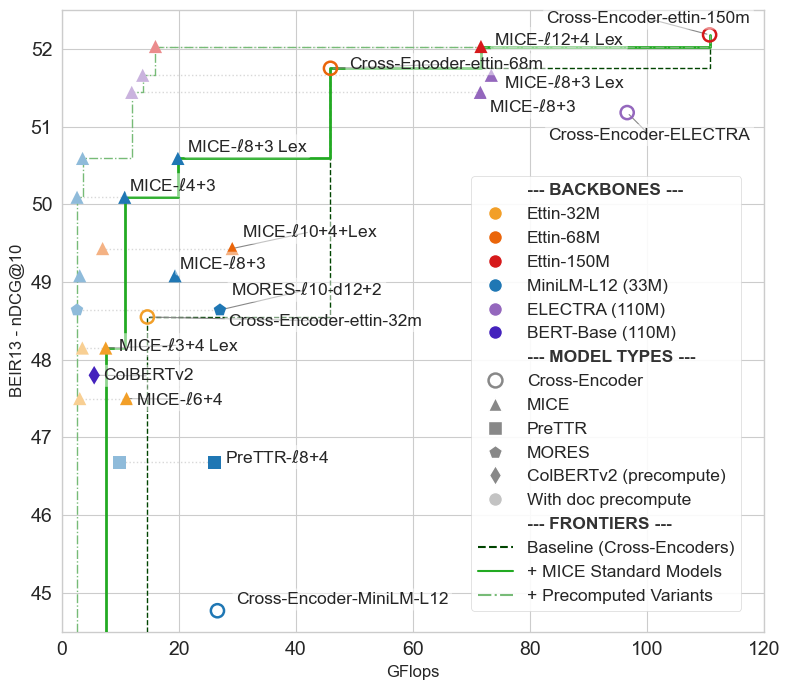

Saved visualization to: figures/mice/pareto_frontier_BEIR13_model_Gflops_precompute.pdf


In [120]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors
from adjustText import adjust_text


def get_family(name):
    n = name.lower()
    if "cross" in n: return "Cross-Encoder"
    if "mice" in n: return "MICE"
    if "prettr" in n: return "PreTTR"
    if "mores" in n: return "MORES"
    if "colbert" in n: return "ColBERTv2 (precompute)"
    return "Other"

def blend_with_white(hex_color, alpha=0.5):
    """Mixes a hex color with white (#ffffff). alpha=1.0 is original, 0.0 is pure white."""
    rgb_orig = mcolors.to_rgb(hex_color)
    rgb_white = (1.0, 1.0, 1.0)
    blended = tuple((1 - alpha) * w + alpha * o for w, o in zip(rgb_white, rgb_orig))
    return mcolors.to_hex(blended)

def get_pareto_frontier(group_df):
    """Returns sorted coordinates for the non-dominated Pareto frontier."""
    if group_df.empty:
        return [], []
    
    # Sort by Latency (ascending) then Performance (descending)
    sorted_df = group_df.sort_values(by=["Latency", "Performance"], ascending=[True, False])
    
    frontier_x = [0]
    frontier_y = [0]
    max_perf_seen = -float("inf")
    
    for _, row in sorted_df.iterrows():
        # A point is on the frontier if it yields strictly better performance
        # than any alternative that is faster than it.
        if row["Performance"] > max_perf_seen:
            frontier_x.append(row["Latency"])
            frontier_y.append(row["Performance"])
            max_perf_seen = row["Performance"]
            
    return frontier_x, frontier_y


# --- 2. Data Collection ---# --- 2. Data Collection ---
data = []
unique_backbones = {}  
model_pairs = {}  # <--- NEW: Dictionary to pair standard and precomp coordinates

for model in benchmarked_models:
    perf = model.results.loc[model.results["dataset"] == dataset_y, metric_key].item()
    base_color = get_color(model.hf_id)
    marker = family_markers.get(get_family(model.name), "o")
    
    bb_id = model.hf_id  
    if bb_id not in unique_backbones:
        unique_backbones[bb_id] = base_color

    # Initialize coordinate tracking for this model pair
    model_pairs[model.name] = {"std": None, "precomp": None}

    # Standard Entry
    std_latency = model.benchmark[bench_key]
    row = {
        "Model": model.name,
        "Latency": std_latency,
        "Performance": perf,
        "Color": base_color,
        "Marker": marker,
        "InLegend": True
    }
    data.append(row)
    model_pairs[model.name]["std"] = (std_latency, perf) # Store standard coords

    # Precompute Entry
    if hasattr(model, 'benchmark_precompute') and model.benchmark_precompute and precompute:
        precomp_latency = model.benchmark_precompute[bench_key]
        data.append({
            "Model": f"{model.name} (precomp)",
            "Latency": precomp_latency,
            "Performance": perf,
            "Color": blend_with_white(base_color, alpha=0.5), 
            "Marker": marker, 
            "InLegend": False 
        })
        model_pairs[model.name]["precomp"] = (precomp_latency, perf) # Store precomp coords

df = pd.DataFrame(data)


# --- 3. Plotting & Point Customization ---
sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=figsize)

texts = []  # Collection tank for adjustText labels

for _, row in df.iterrows():
    is_cross = "cross" in row["Model"].lower()
    
    # Empty circles for baseline Cross-Encoders, filled markers for everything else
    if is_cross and row["Marker"] == "o":
        facecolor = 'none'
        edgecolor = row["Color"]
        linewidths = 1.8
    else:
        facecolor = row["Color"]
        edgecolor = 'none'
        linewidths = 1

    ax.scatter(
        row["Latency"], 
        row["Performance"], 
        facecolor=facecolor,
        edgecolor=edgecolor,
        marker=row["Marker"],
        linewidths=linewidths,
        s=marker_size, 
        label="_",  # Explicitly prevents point clutter in the final legend box
        zorder=5    # Places dots explicitly above frontier strings
    )
    
    # Generate label strings (clean out trailing clutter tags)
    clean_label = row["Model"].replace(" (precomp)", " (pc)")
    
    if row["InLegend"]:
        # Place text directly inside canvas grid (to be algorithmically shifted later)
        txt = ax.text(
            row["Latency"], 
            row["Performance"], 
            clean_label, 
            fontsize=txt_size,
            # fontweight='bold',
            zorder=6,
            bbox=dict(
                boxstyle="round,pad=0.2",   # Adds slightly rounded edges with clean text padding
                facecolor="white",          # Solid white background
                alpha=label_bg_alpha,                  # 60% opaque (shows lines underneath without losing readability)
                edgecolor="none"            # Removes borders around the background plate to avoid clutter
            )
        )
        texts.append(txt)

# ____ Draw lines


for model_name, coords in model_pairs.items():
    if coords["std"] is not None and coords["precomp"] is not None:
        std_x, std_y = coords["std"]
        prec_x, prec_y = coords["precomp"]
        
        # Get the original base color for the line to match the model family
        line_color = get_color(df[df["Model"] == model_name]["Color"].values[0])
        
        ax.plot(
            [std_x, prec_x], 
            [std_y, prec_y], 
            color=line_color,
            linestyle=":",       # Subtle dotted line
            linewidth=1,
            alpha=0.3,           # Blended transparency so it doesn't distract
            zorder=2             # Below everything else
        )

# --- 4. Computing and Drawing Additive Pareto Frontiers ---
mask_cross = df["Model"].str.lower().str.contains("cross")
mask_mice_std = df["Model"].str.lower().str.contains("mice") & ~df["Model"].str.contains(r"\(precomp\)")
mask_mice_precomp = df["Model"].str.lower().str.contains("mice") & df["Model"].str.contains(r"\(precomp\)")

df_baseline = df[mask_cross]
df_tier1 = df[mask_cross | mask_mice_std]
df_tier2 = df[mask_cross | mask_mice_std | mask_mice_precomp]

additive_frontiers = [
    {"df": df_baseline, "label": "Baseline (Cross-Encoders)", "color": "#004400", "style": "--", "width": 1},
    {"df": df_tier1, "label": "+ MICE Standard Models", "color": "#22aa22", "style": "-", "width": 2},
    {"df": df_tier2, "label": "+ Precomputed Variants", "color": "#77bb77", "style": "-.", "width": 1}
]

frontier_handles = []
for tier in additive_frontiers:
    fx, fy = get_pareto_frontier(tier["df"])
    if fx:
        ax.plot(
            fx, fy, 
            drawstyle="steps-post", 
            linestyle=tier["style"], 
            color=tier["color"], 
            linewidth=tier["width"],
            zorder=3  # Keeps frontier boundaries cleanly below data points
        )
        # Create dedicated legend layout line handles
        frontier_handles.append(
            Line2D([0], [0], color=tier["color"], linestyle=tier["style"], linewidth=1.5, label=tier["label"])
        )


# --- 5. Clean Custom Legend Assembly ---
legend_handles = []

# Section A: Backbone Architectures
legend_handles.append(Line2D([0], [0], color='w', label='--- BACKBONES ---', markersize=0))

for bb_id in backbone_names.keys():
    if bb_id in unique_backbones.keys():
        bb_color = unique_backbones[bb_id]
        bb_label = backbone_names.get(bb_id, bb_id)  # Fallback to id string if map name missing
        legend_handles.append(
            Line2D([0], [0], marker='o', color='w', markerfacecolor=bb_color, markersize=10, label=bb_label)
        )

# Section B: Model Types & Family Shapes
legend_handles.append(Line2D([0], [0], color='w', label='--- MODEL TYPES ---', markersize=0))
for family_name, marker_shape in family_markers.items():
    if family_name == "Cross-Encoder":
        legend_handles.append(
            Line2D([0], [0], marker='o', color='w', markerfacecolor='none', 
                   markeredgecolor='#888888', markeredgewidth=1.8, markersize=10, label=family_name)
        )
    else:
        legend_handles.append(
            Line2D([0], [0], marker=marker_shape, color='w', markerfacecolor='#888888', markersize=10, label=family_name)
        )

# Append structural indicator for Precomputed Variants
legend_handles.append(
    Line2D([0], [0], marker='o', color='w', markerfacecolor=blend_with_white('#888888', alpha=0.5), 
           markersize=10, label='With doc precompute')
)

# Section C: Pareto Frontiers
legend_handles.append(Line2D([0], [0], color='w', label='--- FRONTIERS ---', markersize=0))
legend_handles.extend(frontier_handles)

# Unpack labels out cleanly
final_handles = [h for h in legend_handles]
final_labels = [h.get_label() for h in legend_handles]

leg = ax.legend(
    handles=final_handles, 
    labels=final_labels, 
    loc='lower right',           
    bbox_to_anchor=(0.98, 0.02), 
    frameon=True,                
    facecolor='white',           
    framealpha=0.9,                
    edgecolor='lightgray',       
    fontsize=txt_size,          
)

if leg:
    for text in leg.get_texts():
        # Identify your section divider strings
        if text.get_text().startswith('--'):
            text.set_fontweight('bold')
            text.set_color('#333333')       # Makes it a clean dark charcoal gray
            # text.set_fontsize('small')      # Keeps the layout cohesive

# --- 6. Algorithmic Label Positioning ---
# This adjusts and distributes text nodes dynamically avoiding scatter point crossovers


# --- 7. Final Adjustments & Saving ---
ax.set_xlabel(label_map.get(bench_key, bench_key))
ax.set_ylabel(f"{dataset_y} - {metric_key}")
ax.set_xlim(xlim)
ax.set_ylim(ylim)
# ax.set_title(f"Additive Pareto Frontier Analysis ({dataset_y.upper()})", fontweight='bold', fontsize=12, pad=12)

adjust_text(
    texts, 
    ax=ax,
    add_objects=[],
    arrowprops=dict(
        arrowstyle="-", color='#888888', lw=0.8, #connectionstyle="arc3,rad=0.1"
        ),
    only_move={'text':'y'},
    # max_move=(.3, 3),
    # expand=(1.0, 1.2),       
    # force_text=(0.8, 1.9),
    # force_points=(0.1, 0.6),
    # force_static=(1.8, 0.9),
)

plt.tight_layout()
filepath = fig_dir / f"pareto_frontier_{dataset_y}_{bench_key}{'_precompute' if precompute else ''}.pdf"
plt.savefig(filepath, bbox_inches='tight')
plt.show()
print("Saved visualization to:", filepath)

# Analysis

## Distribution of ndcg for Mice-$\ell4$+3 v Mice-$\ell8$+3

In [ ]:
# Main table
import pandas as pd

xps = [
    "train_mice_miniLM_l4|8_ID_withruns",
    "baseline_small_CE_withruns",
    ]

dat_files = []
for xp in xps:
    xp_path = xps_root / xp
    xp_path = xps_root / xp / "dry-run"
    xp_path = get_last_xp(xps_root / xp)
    
    dat_files += list(xp_path.glob("results/models/*/evals/*.dat"))
    print(f"Using xp path: {xp_path}")
    xp_df = process_results(get_results(xp_path))

    datasets = xp_df["dataset"].unique()
    print(f"{len(datasets)} unique datasets : {list(datasets)}")
    # print(f"unique losses : {list(xp_df['loss'].unique())}")
    # print(f"Backbones : {list(xp_df['base'].unique())}")
    display(xp_df.head())
# get dat files
print(f"got {len(dat_files)} runs")

In [ ]:

names_to_ignore = ["ettin"]
runs_per_model = {}

def parse_reranker_results(file_path_or_string):
    """
    Parses a reranker result file into a pandas DataFrame.
    The file is expected to have columns: Metric, QID, Score.
    """
    # Use sep='\s+' to handle multiple spaces or tabs
    # We define the column names manually as the file has no header
    df = pd.read_csv(
        file_path_or_string, 
        sep=r'\s+', 
        names=['Metric', 'QID', 'Score'], 
        header=None
    )
    return df

for dat in dat_files:
    model_name = dat.parent.parent.name
    dataset_name = re.match(r"detailed_(.+).dat", dat.name).group(1)
    runs = runs_per_model.get(model_name,{})
    runs[dataset_name] = parse_reranker_results(dat)
    runs_per_model[model_name] = runs

runs_per_model = {k:v for k,v in runs_per_model.items() if len(v.keys())}
models = list(runs_per_model.keys())



models = [
        model_name
        for model_name in models
        if not any([pattern in model_name for pattern in names_to_ignore])
    ]

datasets = list(runs_per_model[models[0]].keys())
print(f"got runs for models: {models}")
display(runs_per_model[models[0]]["trec2019"])

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_model_comparison(runs_per_model, dataset, models):
    all_data = []

   
    # 1. Combine data
    for model_name in models:
        df = runs_per_model[model_name][dataset].copy()
        df["Model"] = model_name
        all_data.append(df)

    combined_df = pd.concat(all_data, ignore_index=True)

    g = sns.catplot(
        data=combined_df,
        x="Model",
        y="Score",
        hue="Model",  # Fix: Assign x to hue
        col="Metric",
        kind="violin",
        inner="points",
        palette="viridis",
        legend=False,  # Fix: Remove redundant legend
        col_wrap=2,
        height=5,
        aspect=1.2,
        sharey=True,
    )

    # 4. Overlay Averages
    axes = g.axes.flatten()
    metrics = combined_df["Metric"].unique()

    for i, metric in enumerate(metrics):
        ax = axes[i]
        metric_data = combined_df[combined_df["Metric"] == metric]
        means = metric_data.groupby("Model", sort=False)["Score"].mean()

        for j, model_name in enumerate(models):
            avg_val = means[model_name]
            ax.text(
                j,
                avg_val,
                f"{avg_val:.3f}",
                color="black",
                ha="center",
                va="bottom",
                fontweight="bold",
                fontsize=9,
                bbox=dict(facecolor="white", alpha=0.7, lw=0),
            )

    g.set_axis_labels("", "Score Value")
    g.set_titles("{col_name}")
    plt.tight_layout()
    plt.show()


# Usage:
for dataset in datasets:
    print(f"distribution for {dataset}")
    plot_model_comparison(runs_per_model, dataset, models)

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

def plot_all_lexical_dependencies(runs_per_model, dataset, models, metric='nDCG@10'):
    all_comparisons = []
    bm25_name = 'bm25'
    
    # 1. Build a combined dataframe for all models
    df_bm25 = runs_per_model[bm25_name][dataset]
    df_bm25 = df_bm25[df_bm25['Metric'] == metric].set_index('QID')

    for model in models:
        if model == bm25_name: continue
        
        df_model = runs_per_model[model][dataset]
        df_model = df_model[df_model['Metric'] == metric].set_index('QID')
        
        temp_df = pd.DataFrame({
            'BM25 Score': df_bm25['Score'],
            'Delta': df_model['Score'] - df_bm25['Score'],
            'Model': model
        })
        all_comparisons.append(temp_df)

    combined_df = pd.concat(all_comparisons)

    # 2. Use lmplot for side-by-side regression analysis
    sns.set_theme(style="whitegrid")
    g = sns.lmplot(
        data=combined_df, 
        x='BM25 Score', 
        y='Delta', 
        col='Model', 
        hue='Model',
        palette='viridis',
        scatter_kws={'alpha': 0.4},
        line_kws={'lw': 2},
        height=5, 
        aspect=1.0,
        col_wrap=3
    )

    # 3. Add baseline and Correlation coefficients
    for model_name, ax in g.axes_dict.items():
        # Draw baseline at 0
        ax.axhline(0, color='black', linestyle='--', alpha=0.6)
        
        # Calculate correlation for this specific model
        subset = combined_df[combined_df['Model'] == model_name]
        # Drop NaNs if any exist to prevent correlation errors
        subset = subset.dropna(subset=['BM25 Score', 'Delta'])
        
        corr, _ = stats.pearsonr(subset['BM25 Score'], subset['Delta'])
        
        # Display correlation in the plot
        ax.text(0.05, 0.95, f'Pearson r: {corr:.3f}', 
                transform=ax.transAxes, verticalalignment='top',
                fontweight='bold', bbox=dict(facecolor='white', alpha=0.8))

    g.set_axis_labels("BM25 Score (Lexical Signal)", "Gain (Model - BM25)")
    g.fig.suptitle(f'Reranker Gain vs Lexical Baseline Quality ({metric} - {dataset})', y=1.02, fontsize=16)
    
    plt.show()

# Execution
for dataset in datasets:
    plot_all_lexical_dependencies(runs_per_model, dataset, models)

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_bm25_vs_model_direct(runs_per_model, dataset, models, metric='nDCG@10'):
    all_comparisons = []
    bm25_name = 'bm25'
    
    # 1. Get BM25 scores as the anchor
    df_bm25 = runs_per_model[bm25_name][dataset]
    df_bm25 = df_bm25[df_bm25['Metric'] == metric].set_index('QID')

    for model in models:
        if model == bm25_name: continue
        
        df_model = runs_per_model[model][dataset]
        df_model = df_model[df_model['Metric'] == metric].set_index('QID')
        
        temp_df = pd.DataFrame({
            'BM25 Score': df_bm25['Score'],
            'Model Score': df_model['Score'],
            'Model': model
        })
        all_comparisons.append(temp_df)

    combined_df = pd.concat(all_comparisons)

    # 2. Plotting
    g = sns.FacetGrid(combined_df, col="Model", hue="Model", 
                      palette='viridis', height=5, aspect=1, col_wrap=3)

    # Use regplot but disable the regression line if you just want the raw scatter, 
    # or keep it to see the general trend.
    g.map(sns.scatterplot, 'BM25 Score', 'Model Score', alpha=0.5)

    # 3. Add the Identity Line (y=x)
    for ax in g.axes.flatten():
        # Draw a 45-degree dashed line from (0,0) to (1,1)
        ax.plot([0, 1], [0, 1], color='red', linestyle='--', linewidth=2, label='Identity (y=x)')
        ax.set_xlim(-0.05, 1.05)
        ax.set_ylim(-0.05, 1.05)
        
        # Optional: Count how many queries are above/below the line
        # This gives a quick "Win Rate" visual
        ax.fill_between([0, 1], [0, 1], 1, color='green', alpha=0.05) # "Model Win" zone
        ax.fill_between([0, 1], 0, [0, 1], color='red', alpha=0.05)   # "BM25 Win" zone

    g.set_axis_labels("BM25 Score", "Model Score")
    g.figure.suptitle(f'Performance Comparison on {dataset}: BM25 vs Rerankers ({metric})', y=1.05, fontsize=16)
    
    plt.tight_layout()
    plt.show()

# plot_bm25_vs_model_direct(runs_per_model, "trec2020", models)
# Execution
for dataset in datasets:
    plot_bm25_vs_model_direct(runs_per_model, dataset, models)

# Ablations

## Booleans Ablation

In [ ]:
# Main table
import pandas as pd
from IPython.display import display, HTML

xps = [
    "train_mice_miniLM_bools",
]


def get_tag(tagspath: str, regex: str) -> dict:
    match = re.search(regex, tagspath)
    if match:
        return match.group(1)
    return None


raw_dfs = []
for xp in xps:
    xp_path = xps_root / xp / "dry-run"
    raw_dfs.append(process_results(get_results(xp_path)))

df = pd.concat(raw_dfs)


# Define regex patterns for tags
tags = {
    "base": r"base=(.*)_global",
    "global_cls_token": r"global_cls_token=(.*)_mask_cls_to_doc",
    "mask_query_to_cls": r"mask_query_to_cls=(.*)_loss",
    "mask_cls_to_doc": r"mask_cls_to_doc=(.*)_mask",
}

# rm row without "scorer" tag
df = df[df["scorer"].notna()]
# Split "scorer" into separate columns using the regex patterns
for tag_name, pattern in tags.items():
    df[tag_name] = df["scorer"].apply(lambda x: get_tag(x, pattern))


# Ensure the boolean columns are boolean type
bool_cols = ["global_cls_token", "mask_query_to_cls", "mask_cls_to_doc"]
for col in bool_cols:
    df[col] = df[col].map({"True": True, "False": False})

datasets = list(df["dataset"].unique())
print(f"{len(datasets)} unique datasets : {datasets}")
# print(f"unique losses : {list(df["loss"].unique())}")
# print(f"Backbones : {list(df["base"].unique())}")


display(HTML(df.iloc[0:5].to_html()))

In [ ]:
# Plot in-domain nDCG@10_mean for each combination of boolean params

import matplotlib.pyplot as plt

for dataset in ["Mean In Domain", "mean"]:
    # Filter for in-domain dataset (assuming msmarco_dev is in-domain)
    in_domain_df = df[df["dataset"] == dataset].copy()

    # Group by the boolean combinations and compute mean of nDCG@10_mean and mean of nDCG@10_var
    grouped = (
        in_domain_df.groupby(bool_cols)
        .agg(mean_nDCG=("nDCG@10_mean", "mean"), mean_var=("nDCG@10_var", "mean"))
        .reset_index()
    )

    # Compute std as sqrt of mean variance
    grouped["std_nDCG"] = np.sqrt(grouped["mean_var"])

    # Create a combination label
    grouped["combination"] = grouped[bool_cols].astype(str).agg("_".join, axis=1)

    # Plot
    fig, ax = plt.subplots(figsize=(10, 6))
    bars = sns.barplot(data=grouped, x="combination", y="mean_nDCG", ax=ax)
    ax.errorbar(
        x=range(len(grouped)),
        y=grouped["mean_nDCG"],
        yerr=grouped["std_nDCG"],
        fmt="none",
        c="black",
        capsize=3,
        elinewidth=1,
        alpha=0.8,
    )
    ax.set_title("Mean nDCG@10 for Boolean Parameter Combinations (In-Domain)")
    ax.set_xlabel(
        "Parameter Combination (global_cls_token_mask_query_to_cls_mask_cls_to_doc)"
    )
    ax.set_ylabel("Mean nDCG@10")
    plt.xticks(rotation=45)
    plt.ylim(0.48, 0.68)
    plt.tight_layout()
    plt.show()

    # Display the grouped data
    display(grouped)

In [ ]:
# Plot impact of each boolean parameter separately

# Create subplots for each boolean parameter
fig, axes = plt.subplots(1, 3, figsize=(10, 5))
fig.suptitle(
    "Impact of Each Boolean Parameter on Mean nDCG@10 ({dataset})".format(
        dataset=dataset
    )
)

grouped_dfs = []
for ax, param in zip(axes, bool_cols):
    grouped = (
        in_domain_df.groupby(param)
        .agg(mean_nDCG=("nDCG@10_mean", "mean"), mean_var=("nDCG@10_var", "mean"))
        .reset_index()
    )
    grouped["std_nDCG"] = np.sqrt(grouped["mean_var"])

    sns.barplot(data=grouped, x=param, y="mean_nDCG", ax=ax)
    ax.errorbar(
        x=range(len(grouped)),
        y=grouped["mean_nDCG"],
        yerr=grouped["std_nDCG"],
        fmt="none",
        c="black",
        capsize=3,
        elinewidth=1,
        alpha=0.8,
    )
    ax.set_title(f"Impact of {param}")
    ax.set_xlabel(param)
    ax.set_ylabel("Mean nDCG@10")
    ax.set_ylim(0.48, 0.53)

    grouped_dfs.append(grouped)

plt.tight_layout()
plt.show()

## Mice MiniLM X+3 - Vanilla vs Inverted

In [ ]:
# Main table
import pandas as pd

xps = {
    "train_mice_miniLM_lX+3": "Inverted Cross-Self Attn",
    "train_mice_miniLM_lX+3_vanilla": "Vanilla Self-Cross Attn",
}


def get_xp_df(xp):
    xp_path = xps_root / xp / "dry-run"
    xp_path = get_last_xp(xps_root / xp)
    xp_path = xps_root / xp / "20260425_161300" #
    if 'vanilla' in xp: 
        xp_path = get_last_xp(xps_root / xp)
    else:
        xp_path = xps_root / xp / "20260425_161300" #
        xp_path = get_last_xp(xps_root / xp)
    print(f"Using xp path: {xp_path}")
    df = process_results(get_results(xp_path))

    datasets = df["dataset"].unique()
    print(f"{len(datasets)} unique datasets : {list(datasets)}")
    # print(f"unique losses : {list(df['loss'].unique())}")
    # print(f"Backbones : {list(df['base'].unique())}")

    display(df.head())
    return df

xp_dfs = {xp: get_xp_df(xp) for xp in xps.keys()}

In [ ]:
#filter 'n_contextualization_layers' is not null
metric = "nDCG@10"
metric_mean = f"{metric}_mean"
metric_var = f"{metric}_var"

# Plot for each dataset
for dataset_name in ["Mean In Domain", "mean"]:
    # Create figure with publication quality
    fig, ax = plt.subplots(figsize=(8, 5))

    for xp, df in xp_dfs.items():
        # plot nDCG@10_mean /pm nDCG@10_var as a function of n_contextualization_layers
        df["n_contextualization_layers"] = pd.to_numeric(df["n_contextualization_layers"], errors="coerce")
        df[metric_mean] = pd.to_numeric(df[metric_mean], errors="coerce")
        df[metric_var] = pd.to_numeric(df[metric_var], errors="coerce")
        df = df[df["n_contextualization_layers"].notnull()]
        dataset_df = df[df["dataset"] == dataset_name].copy()
        if len(dataset_df) == 0:
            print(f"No data found for dataset: {dataset_name}")
            continue
        
        # Group by n_contextualization_layers and compute aggregated statistics
        grouped = dataset_df.groupby("n_contextualization_layers", dropna=False).agg(
            mean_nDCG=(metric_mean, "mean"),
            std_nDCG=(metric_var, lambda x: np.sqrt(x.mean())),  # sqrt of mean variance
            count=(metric_mean, "count")
        ).reset_index()

        grouped = grouped.sort_values("n_contextualization_layers")

        ax.errorbar(
            grouped["n_contextualization_layers"],
            grouped["mean_nDCG"],
            yerr=grouped["std_nDCG"],
            fmt="o-",
            markersize=6,
            linewidth=2,
            capsize=5,
            capthick=1.5,
            # color="#1f77b4",
            # ecolor="#1f77b4",
            alpha=0.8,
            label=f"{xps[xp]} - {metric}"
        )

    # Formatting
    ax.set_xlabel("Number of Contextualization Layers", fontsize=11, fontweight="normal")
    ax.set_ylabel("nDCG@10", fontsize=11, fontweight="normal")
    ax.set_title(f"{metric} vs Contextualization Layers ({dataset_name})", fontsize=12, fontweight="normal")
    ax.grid(True, alpha=0.3, linestyle="--")
    ax.legend(frameon=True, loc="best", fontsize=9)
    ax.set_xticks(grouped["n_contextualization_layers"].unique())
    # ax.set_ylim(.50, .512)  # nDCG is between 0 and 1
    plt.tight_layout()
    plt.savefig(fig_dir / f"nDCG10_vs_ContextLayers_{dataset_name.replace(' ', '_')}_vs_vanilla.pdf")
    plt.show()
    # Display grouped results
    print(f"\nAggregated nDCG@10 Statistics by Contextualization Layers ({dataset_name}):")
        # display(grouped)